Assumed true AUC = 0.50, noise (std) = 0.05

k =   1 models tried:
  E[best AUC] = 0.500
  inflation   = +0.000
  95th pct    = 0.582

k =   5 models tried:
  E[best AUC] = 0.558
  inflation   = +0.058
  95th pct    = 0.617

k =  20 models tried:
  E[best AUC] = 0.594
  inflation   = +0.094
  95th pct    = 0.640

k = 100 models tried:
  E[best AUC] = 0.625
  inflation   = +0.125
  95th pct    = 0.664



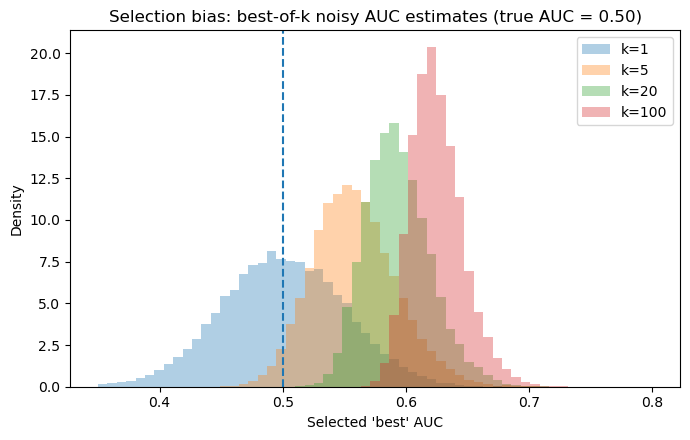

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# Simulation settings
true_auc = 0.50          # no real signal
sigma = 0.05             # noise of CV estimate
n_trials = 20000         # Monte Carlo trials
ks = [1, 5, 20, 100]     # number of models/hyperparameter settings tried

results = {}
for k in ks:
    # k noisy AUC estimates around the true AUC, pick the "best"
    estimates = rng.normal(loc=true_auc, scale=sigma, size=(n_trials, k))
    results[k] = estimates.max(axis=1)

print(f"Assumed true AUC = {true_auc:.2f}, noise (std) = {sigma:.2f}\n")
for k in ks:
    best = results[k]
    print(f"k = {k:3d} models tried:")
    print(f"  E[best AUC] = {best.mean():.3f}")
    print(f"  inflation   = {best.mean() - true_auc:+.3f}")
    print(f"  95th pct    = {np.quantile(best, 0.95):.3f}\n")

# Plot distributions
plt.figure(figsize=(7, 4.5))
bins = np.linspace(0.35, 0.80, 60)
for k in ks:
    plt.hist(results[k], bins=bins, alpha=0.35, density=True, label=f"k={k}")
plt.axvline(true_auc, linestyle="--")
plt.title("Selection bias: best-of-k noisy AUC estimates (true AUC = 0.50)")
plt.xlabel("Selected 'best' AUC")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()